## Import libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.spatial.distance import cdist
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [6]:
data = pd.read_excel('E:/machine_learning_1/ML1_group_assignemnt/Madrid_Rental_Properties_ML1-/raw_data/Houses for rent in Madrid.xlsx')
print(f"Shape: {data.shape}")
data.head()

Shape: (2089, 15)


,Id,District,Address,Number,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
0,1,Ciudad Lineal,Piso en Quintana,NaN,Quintana,1300,2.0,72,3.0,1.0,1.0,0,0,0,0
1,2,Ciudad Lineal,Piso en calle de Arturo Soria,NaN,Costillares,3000,5.0,260,2.0,1.0,1.0,0,0,0,0
2,3,Ciudad Lineal,Piso en calle de Vicente Muzas,4,Colina,1300,2.0,100,3.0,1.0,1.0,0,0,0,0
3,4,Ciudad Lineal,Piso en calle Badajoz,NaN,San Pascual,1600,3.0,120,4.0,1.0,1.0,0,0,0,0
4,5,Ciudad Lineal,Piso en calle de Nuestra Señora del Villar,9,Ventas,800,2.0,60,3.0,1.0,0.0,0,0,0,0


## Inspect data

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,2089.0,1094.026807,630.612544,1.0,550.0,1094.0,1636.0,2188.0
Rent,2089.0,1932.249402,1495.474485,450.0,950.0,1400.0,2500.0,16000.0
Bedrooms,2000.0,2.483000,1.305206,0.0,2.0,2.0,3.0,8.0
Sq.Mt,2089.0,128.919579,115.745014,15.0,65.0,90.0,147.0,1250.0
Floor,1948.0,25.662731,975.065350,-1.0,2.0,3.0,5.0,43039.0
Outer,1927.0,0.867151,0.339500,0.0,1.0,1.0,1.0,1.0
Elevator,1956.0,0.880879,0.324013,0.0,1.0,1.0,1.0,1.0
Penthouse,2089.0,0.080900,0.272747,0.0,0.0,0.0,0.0,1.0
Cottage,2089.0,0.042125,0.200923,0.0,0.0,0.0,0.0,1.0
Duplex,2089.0,0.030637,0.172373,0.0,0.0,0.0,0.0,1.0


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2089 entries, 0 to 2088
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2089 non-null   int64  
 1   District      2089 non-null   str    
 2   Address       2089 non-null   str    
 3   Number        747 non-null    str    
 4   Area          2085 non-null   str    
 5   Rent          2089 non-null   int64  
 6   Bedrooms      2000 non-null   float64
 7   Sq.Mt         2089 non-null   int64  
 8   Floor         1948 non-null   float64
 9   Outer         1927 non-null   float64
 10  Elevator      1956 non-null   float64
 11  Penthouse     2089 non-null   int64  
 12  Cottage       2089 non-null   int64  
 13  Duplex        2089 non-null   int64  
 14  Semidetached  2089 non-null   int64  
dtypes: float64(4), int64(7), str(4)
memory usage: 244.9 KB


In [9]:
print(data.isnull().sum())

Id                 0
District           0
Address            0
Number          1342
Area               4
Rent               0
Bedrooms          89
Sq.Mt              0
Floor            141
Outer            162
Elevator         133
Penthouse          0
Cottage            0
Duplex             0
Semidetached       0
dtype: int64


In [10]:
data.rename(columns={'Sq.Mt': 'square_meters'}, inplace=True)
# Convert all column names to lowercase snake_case
data.columns = data.columns.str.lower().str.replace(' ', '_')

print("Cleaned columns:", data.columns.tolist())

Cleaned columns: ['id', 'district', 'address', 'number', 'area', 'rent', 'bedrooms', 'square_meters', 'floor', 'outer', 'elevator', 'penthouse', 'cottage', 'duplex', 'semidetached']


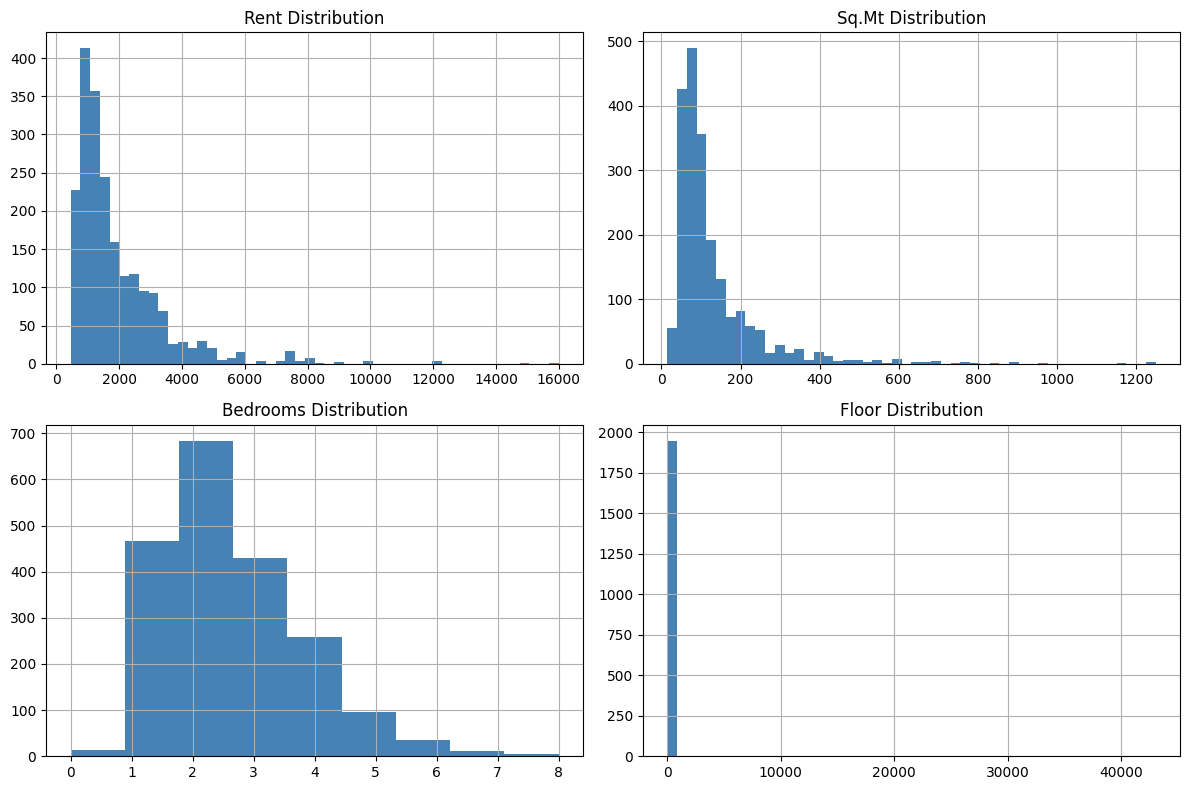

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
data['rent'].hist(bins=50, ax=axes[0,0], color='steelblue'); axes[0,0].set_title('Rent Distribution')
data['square_meters'].hist(bins=50, ax=axes[0,1], color='steelblue'); axes[0,1].set_title('Sq.Mt Distribution')
data['bedrooms'].hist(bins=9, ax=axes[1,0], color='steelblue'); axes[1,0].set_title('Bedrooms Distribution')
data['floor'].hist(bins=50, ax=axes[1,1], color='steelblue'); axes[1,1].set_title('Floor Distribution')
plt.tight_layout()
plt.show()

## Drop Columns not useful
- ID = never relevant its just a row identifier
- Address = text, we are not using NLP
- Number = high cardinality (large number of distinct values)
- Area = 140 categories, we will instead use **District** for location

In [12]:
data_clean = data.drop(columns=['id', 'address', 'number', 'area'])

In [13]:
data_clean.columns

Index(['district', 'rent', 'bedrooms', 'square_meters', 'floor', 'outer',
       'elevator', 'penthouse', 'cottage', 'duplex', 'semidetached'],
      dtype='str')

In [14]:
numeric_cols = data_clean.select_dtypes(include=['number']).columns
categorical_cols = data_clean.select_dtypes(include=['object']).columns

print(numeric_cols)
print()
print(categorical_cols)

Index(['rent', 'bedrooms', 'square_meters', 'floor', 'outer', 'elevator',
       'penthouse', 'cottage', 'duplex', 'semidetached'],
      dtype='str')

Index(['district'], dtype='str')


## Handle Missing Values
- Bedrooms (89 missing) =  impute with **median**, safe for a clustering features
- Floor (141 + 1 anomaly) =  impute with **median**
- Outer (162 missing) =  impute with **mode**
- Elevator (133 missing) = impute with **mode**

In [15]:
data_clean.isnull().sum()

district           0
rent               0
bedrooms          89
square_meters      0
floor            141
outer            162
elevator         133
penthouse          0
cottage            0
duplex             0
semidetached       0
dtype: int64

In [16]:
data_clean['floor'].max()

np.float64(43039.0)

In [17]:
data_clean.loc[data_clean['floor'] > 30, 'floor'] = np.nan

In [18]:
data_clean['bedrooms'] = data_clean['bedrooms'].fillna(data_clean['bedrooms'].median())
data_clean['floor'] = data_clean['floor'].fillna(data_clean['floor'].median())
data_clean['outer'] = data_clean['outer'].fillna(data_clean['outer'].mode()[0])
data_clean['elevator'] = data_clean['elevator'].fillna(data_clean['elevator'].mode()[0])

In [19]:
data_clean['floor'].max()

np.float64(29.0)

### Important: 'why didn't you use inplace = True, if you don't do it then the changes won't be made permanent in the data_clean?'

- Since data_clean was created as a slice/copy of the original data, inplace = True would only modify a temporary object rather than the actual data

### Why did we use the median/mode?

- These are robust to outliers and preserve the distribution shape

In [20]:
data_clean.isnull().sum()

district         0
rent             0
bedrooms         0
square_meters    0
floor            0
outer            0
elevator         0
penthouse        0
cottage          0
duplex           0
semidetached     0
dtype: int64

### Remove Outliers
- Since we are going to be doing **K-means** it's fundamental to remove outliers as it's very sensitive do to the centroids getting pulled distorting the clusters
- For this we will use IQR

### Columns not to Touch
- Outliers on binary columns won't be touched as they're categorical
- 'bedrooms' doesn't need IQR as its range is (0 - 8) which is natural

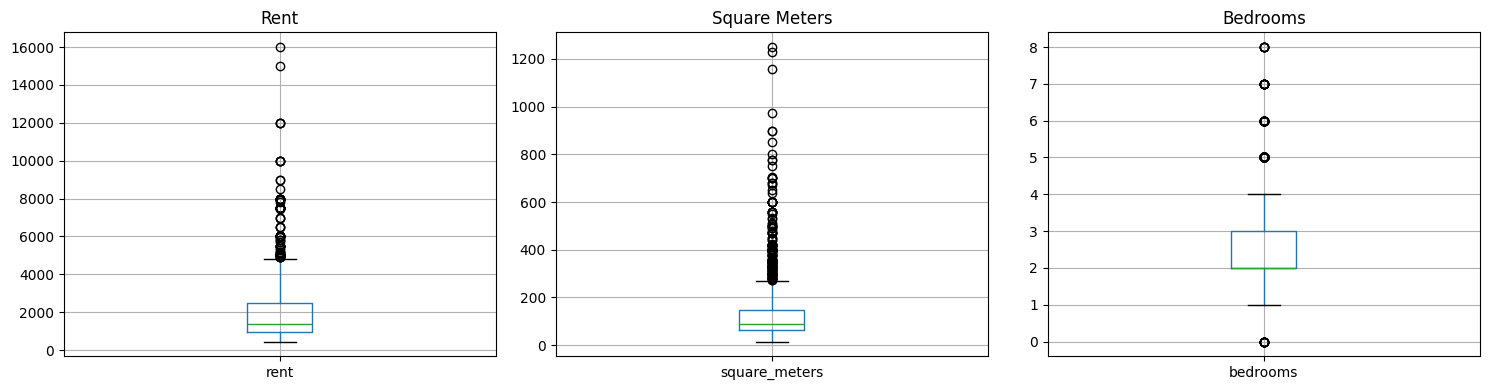

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
data_clean.boxplot(column='rent', ax=axes[0]); axes[0].set_title('Rent')
data_clean.boxplot(column='square_meters', ax=axes[1]); axes[1].set_title('Square Meters')
data_clean.boxplot(column='bedrooms', ax=axes[2]); axes[2].set_title('Bedrooms')
plt.tight_layout()
plt.show()

In [22]:
def remove_outliers_iqr(data, column, factor=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR

    before = len(data)
    df_filtered = data[(data[column] >= lower) & (data[column] <= upper)]
    print(f"{column}: removed {before - len(df_filtered)} outliers (range: {lower:.0f} - {upper:.0f})")

    return df_filtered

df_clean = remove_outliers_iqr(data_clean, 'rent')
df_clean = remove_outliers_iqr(data_clean, 'square_meters')

print(f"\nFinal shape after outlier removal: {df_clean.shape}")

rent: removed 94 outliers (range: -1375 - 4825)
square_meters: removed 167 outliers (range: -58 - 270)

Final shape after outlier removal: (1922, 11)


## Feature Selection for Clustering

- Rent, Square_meters, Bedrooms: Core property characteristics that define market segments
- Floor: Higher floors often correlate with price/desirability
- Binary features: Property type indicators that differentiate segments
- District: Location is critical for real estate a flat in Salamanca != a flat in Carabanchel

In [23]:
numeric_cols

Index(['rent', 'bedrooms', 'square_meters', 'floor', 'outer', 'elevator',
       'penthouse', 'cottage', 'duplex', 'semidetached'],
      dtype='str')

In [24]:
numerical_features = ['rent', 'bedrooms', 'square_meters', 'floor']
binary_features = ['outer', 'elevator', 'penthouse', 'cottage', 'duplex', 'semidetached']

# categorical (one-hot encoding)
district_dummies = pd.get_dummies(df_clean['district'], prefix='district', drop_first=False)

# district make it all lowercase to keep formatting consistency
district_dummies.columns = district_dummies.columns.str.replace(' ', '_')

# combine and concat
clustering_features = numerical_features + binary_features
df_clustering = pd.concat([df_clean[clustering_features], district_dummies], axis=1)

In [25]:
print(f"Clustering dataframe shape: {df_clustering.shape}")
print(f"Features: {df_clustering.columns.tolist()}")

Clustering dataframe shape: (1922, 30)
Features: ['rent', 'bedrooms', 'square_meters', 'floor', 'outer', 'elevator', 'penthouse', 'cottage', 'duplex', 'semidetached', 'district_Arganzuela', 'district_Barajas', 'district_Carabanchel', 'district_Centro', 'district_Chamartín', 'district_Chamberí', 'district_Ciudad_Lineal', 'district_Fuencarral', 'district_Hortaleza', 'district_Latina', 'district_Moncloa', 'district_Moratalaz', 'district_Puente_Vallecas', 'district_Retiro', 'district_Salamanca', 'district_San_Blás', 'district_Tetuán', 'district_Usera', 'district_Vicálvaro', 'district_Villa_de_Vallecas']


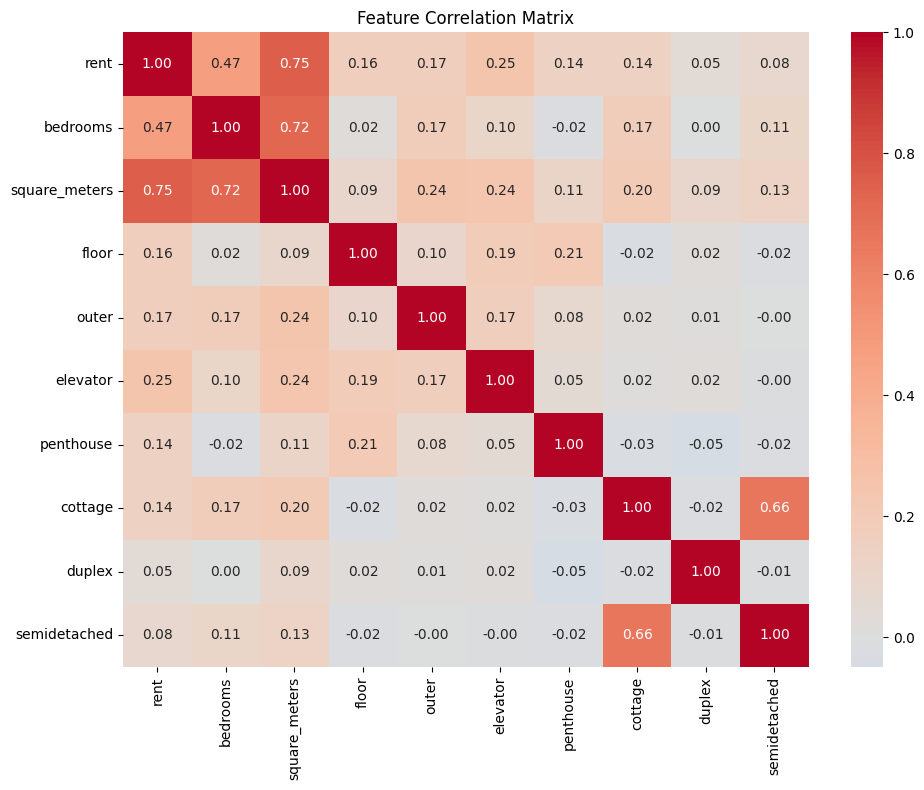

In [26]:
corr = df_clustering[['rent', 'bedrooms', 'square_meters', 'floor', 'outer', 'elevator', 'penthouse', 'cottage', 'duplex', 'semidetached']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [27]:
df_clustering.dtypes

rent                            int64
bedrooms                      float64
square_meters                   int64
floor                         float64
outer                         float64
elevator                      float64
penthouse                       int64
cottage                         int64
duplex                          int64
semidetached                    int64
district_Arganzuela              bool
district_Barajas                 bool
district_Carabanchel             bool
district_Centro                  bool
district_Chamartín               bool
district_Chamberí                bool
district_Ciudad_Lineal           bool
district_Fuencarral              bool
district_Hortaleza               bool
district_Latina                  bool
district_Moncloa                 bool
district_Moratalaz               bool
district_Puente_Vallecas         bool
district_Retiro                  bool
district_Salamanca               bool
district_San_Blás                bool
district_Tet

### Standardize Data
- K-means uses Eucledian distance
- If we don't scale variables like **rent** with large values (e.g 1000 - 10000) will completely dominate variables like **bedrooms** (0 - 8)

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering)

# Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=df_clustering.columns, index=df_clustering.index)
print(X_scaled_df.describe().round(2))

          rent  bedrooms  square_meters    floor    outer  elevator  \
count  1922.00   1922.00        1922.00  1922.00  1922.00   1922.00   
mean     -0.00     -0.00           0.00    -0.00     0.00     -0.00   
std       1.00      1.00           1.00     1.00     1.00      1.00   
min      -1.25     -2.14          -1.63    -1.53    -2.56     -2.73   
25%      -0.73     -0.95          -0.71    -0.52     0.39      0.37   
50%      -0.31     -0.24          -0.26    -0.18     0.39      0.37   
75%       0.54      0.71           0.37     0.50     0.39      0.37   
max       8.71      4.52           3.15     8.62     0.39      0.37   

       penthouse  cottage   duplex  semidetached  ...  district_Moncloa  \
count    1922.00  1922.00  1922.00       1922.00  ...           1922.00   
mean        0.00     0.00     0.00         -0.00  ...             -0.00   
std         1.00     1.00     1.00          1.00  ...              1.00   
min        -0.29    -0.09    -0.17         -0.06  ...       

### Iterate through the different K's to calculate silhouette

For = 2 clusters, the average silhouette_score is : 0.171


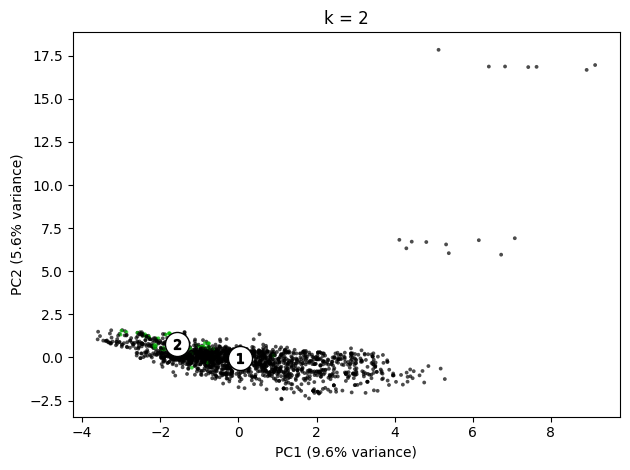

For = 3 clusters, the average silhouette_score is : 0.059


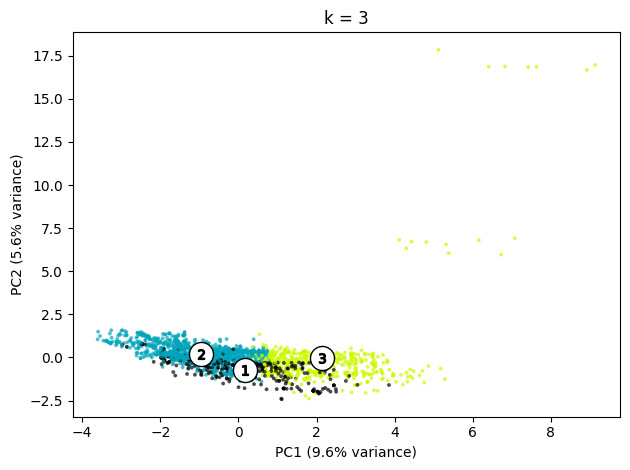

For = 4 clusters, the average silhouette_score is : 0.080


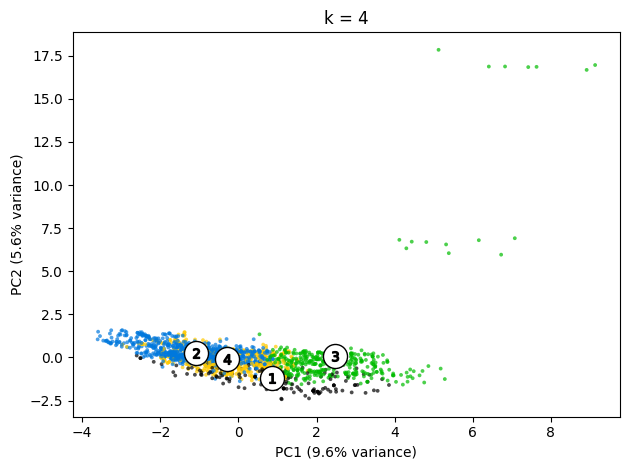

For = 5 clusters, the average silhouette_score is : 0.099


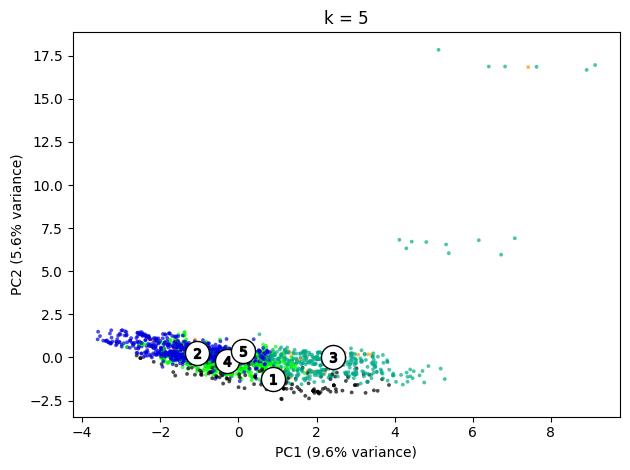

For = 6 clusters, the average silhouette_score is : 0.104


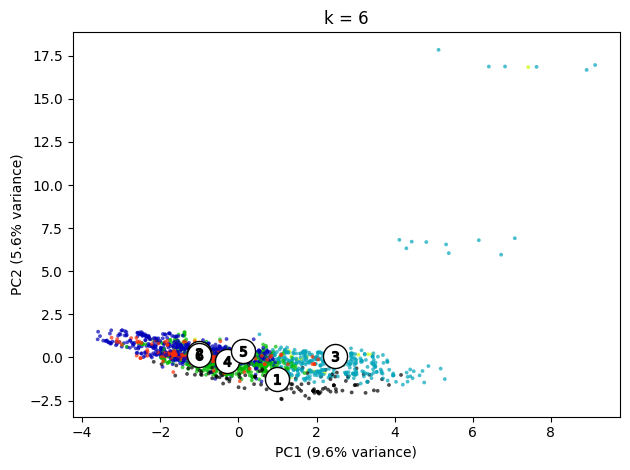

For = 7 clusters, the average silhouette_score is : 0.129


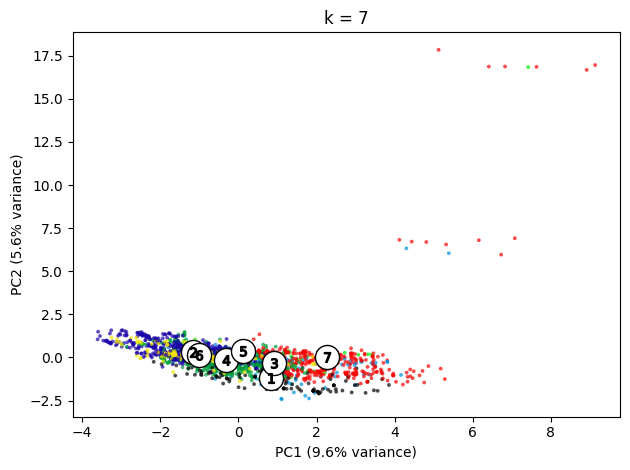

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

k = [2, 3, 4, 5, 6, 7]
inertia = []
silhouettes = []

for n_clusters in k:
    cluster = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = cluster.fit_predict(X_scaled)
    inertia.append(cluster.inertia_)

    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouettes.append("{:.3f}".format(silhouette_avg))
    print(
        "For =", n_clusters, "clusters, the average silhouette_score is : {:.3f}".format(silhouette_avg)
    )

    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        y_lower = y_upper + 10

    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)

    # Transform centers to PCA space
    centers_pca = pca.transform(cluster.cluster_centers_)

    plt.figure()
    plt.scatter(
        X_pca[:, 0], X_pca[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    plt.scatter(
        centers_pca[:, 0],
        centers_pca[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=300,
        edgecolor="k",
    )

    for i, c in enumerate(centers_pca):
        plt.scatter(c[0], c[1], marker="$%d$" % (i+1), alpha=1, s=50, edgecolor="k")

    plt.title(f"k = {n_clusters}")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
    plt.tight_layout()
    plt.show()

### Plot different metrics

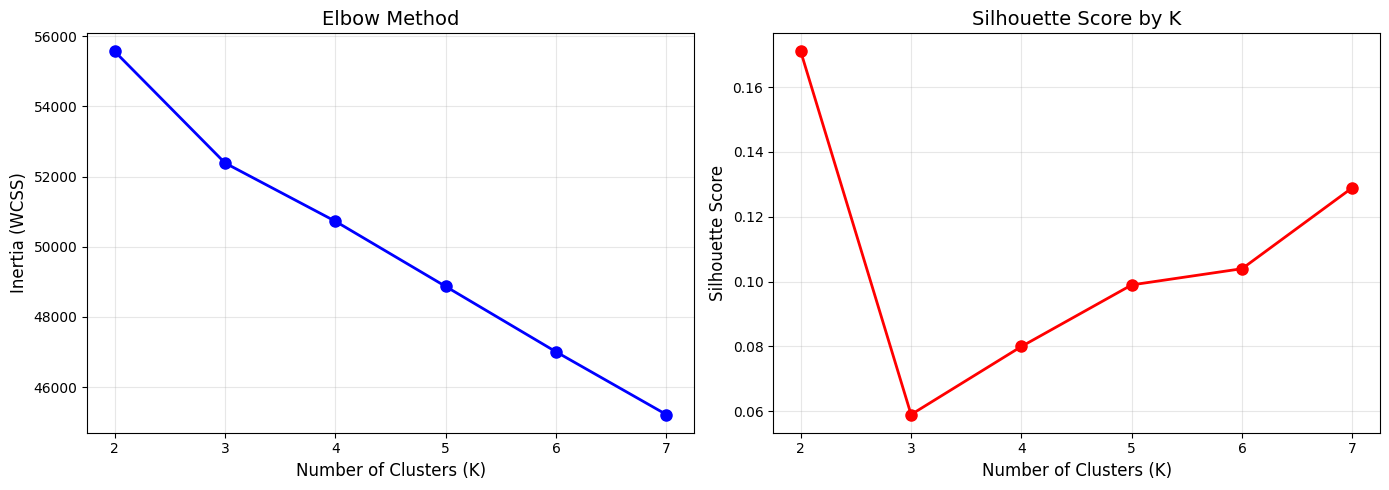

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14)
axes[0].set_xticks(k)
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(k, [float(s) for s in silhouettes], 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score by K', fontsize=14)
axes[1].set_xticks(k)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Same steps above but removing district columns

For = 2 clusters, the average silhouette_score is : 0.440


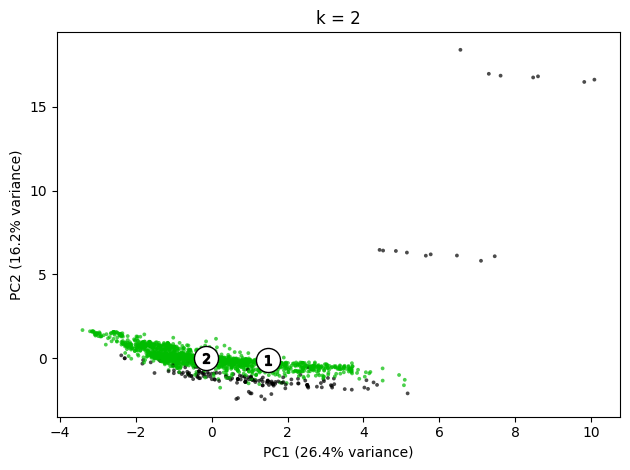

For = 3 clusters, the average silhouette_score is : 0.373


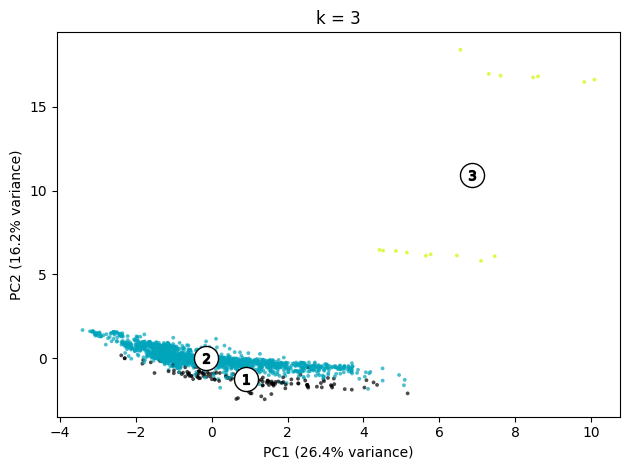

For = 4 clusters, the average silhouette_score is : 0.345


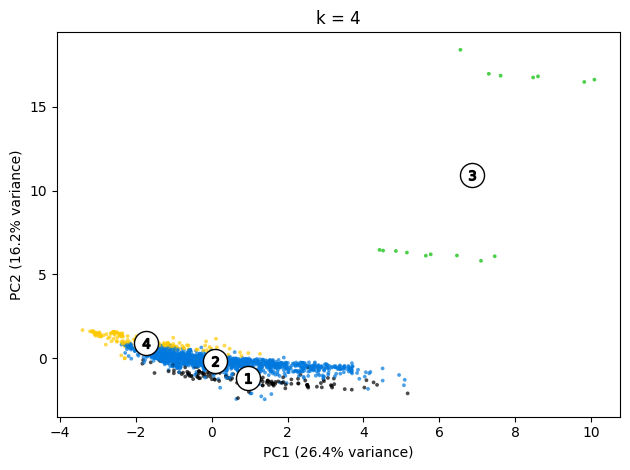

For = 5 clusters, the average silhouette_score is : 0.357


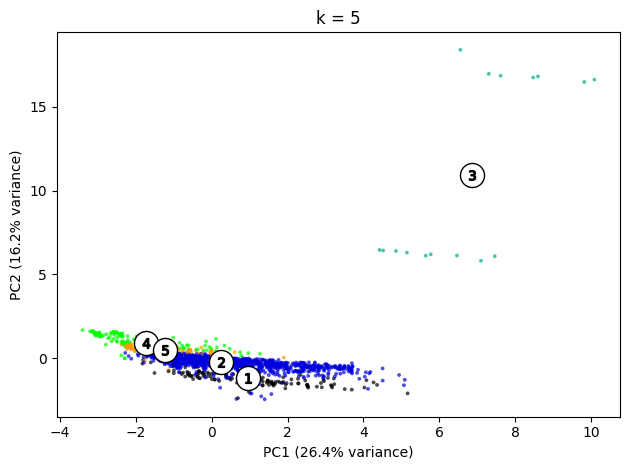

For = 6 clusters, the average silhouette_score is : 0.386


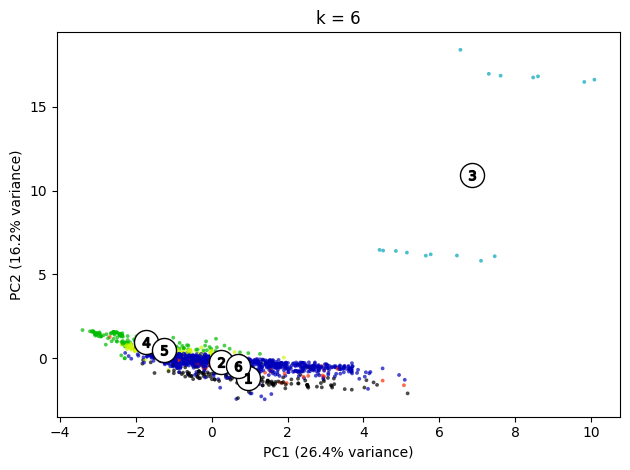

For = 7 clusters, the average silhouette_score is : 0.406


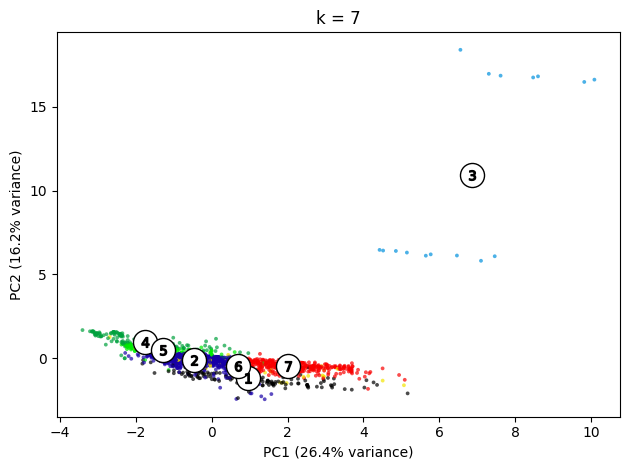

In [31]:
# Remove district columns, scale separately
non_district_cols = [col for col in df_clustering.columns if not col.startswith('district_')]
X_no_district = df_clustering[non_district_cols]

scaler_nd = StandardScaler()
X_scaled_nd = scaler_nd.fit_transform(X_no_district)

# PCA for visualization
pca_nd = PCA(n_components=2)
X_pca_nd = pca_nd.fit_transform(X_scaled_nd)

# K-Means loop
k = [2, 3, 4, 5, 6, 7]
inertia_nd = []
silhouettes_nd = []

for n_clusters in k:
    cluster = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = cluster.fit_predict(X_scaled_nd)
    inertia_nd.append(cluster.inertia_)

    silhouette_avg = silhouette_score(X_scaled_nd, cluster_labels)
    silhouettes_nd.append("{:.3f}".format(silhouette_avg))
    print(
        "For =", n_clusters, "clusters, the average silhouette_score is : {:.3f}".format(silhouette_avg)
    )

    sample_silhouette_values = silhouette_samples(X_scaled_nd, cluster_labels)
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        y_lower = y_upper + 10

    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    centers_pca = pca_nd.transform(cluster.cluster_centers_)

    plt.figure()
    plt.scatter(
        X_pca_nd[:, 0], X_pca_nd[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )
    plt.scatter(
        centers_pca[:, 0], centers_pca[:, 1],
        marker="o", c="white", alpha=1, s=300, edgecolor="k",
    )
    for i, c in enumerate(centers_pca):
        plt.scatter(c[0], c[1], marker="$%d$" % (i+1), alpha=1, s=50, edgecolor="k")

    plt.title(f"k = {n_clusters}")
    plt.xlabel(f"PC1 ({pca_nd.explained_variance_ratio_[0]*100:.1f}% variance)")
    plt.ylabel(f"PC2 ({pca_nd.explained_variance_ratio_[1]*100:.1f}% variance)")
    plt.tight_layout()
    plt.show()

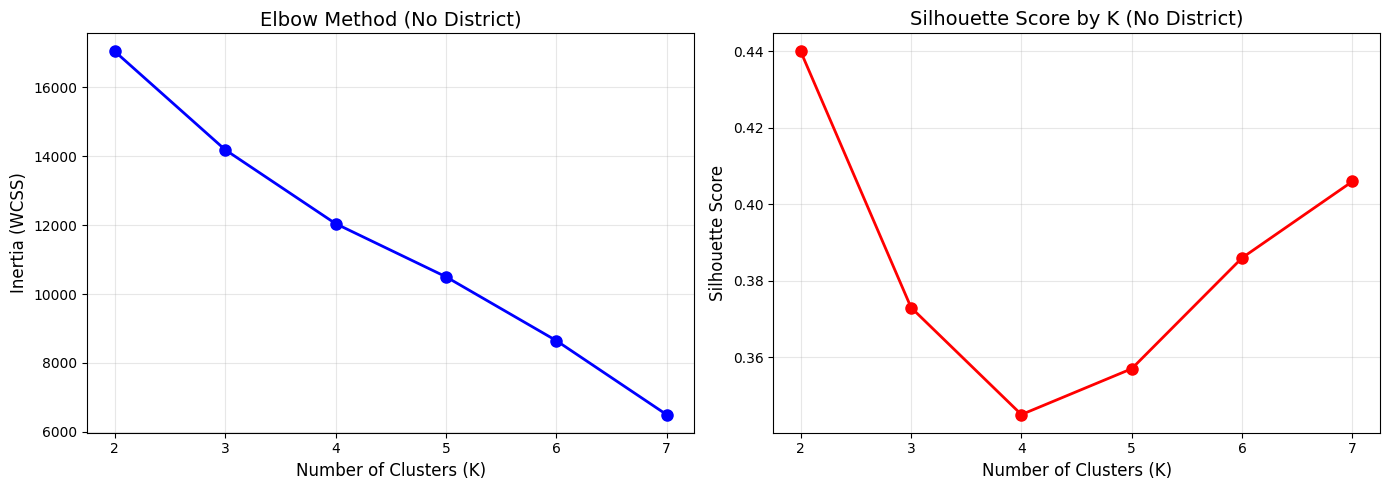

In [32]:
# Elbow + Silhouette plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k, inertia_nd, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method (No District)', fontsize=14)
axes[0].set_xticks(k)
axes[0].grid(True, alpha=0.3)

axes[1].plot(k, [float(s) for s in silhouettes_nd], 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score by K (No District)', fontsize=14)
axes[1].set_xticks(k)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Fit the Model (K-means)

In [33]:
OPTIMAL_K = 4

final_km = KMeans(n_clusters=OPTIMAL_K, n_init=25, max_iter=300, random_state=42)
final_km.fit(X_scaled_nd)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",25
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [34]:
df_clean['cluster'] = final_km.labels_

In [35]:

print(f"Final Inertia: {final_km.inertia_:.1f}")
print(f"Final Silhouette Score: {silhouette_score(X_scaled_nd, final_km.labels_):.4f}")
print(f"\nCluster sizes:")
print(df_clean['cluster'].value_counts().sort_index())
print(f"\nCluster distribution (%):")
print((df_clean['cluster'].value_counts(normalize=True).sort_index() * 100).round(1))

Final Inertia: 11211.3
Final Silhouette Score: 0.3091

Cluster sizes:
cluster
0    1161
1       7
2     529
3     225
Name: count, dtype: int64

Cluster distribution (%):
cluster
0    60.4
1     0.4
2    27.5
3    11.7
Name: proportion, dtype: float64


### Profile the Clusters
- We will translate the clusters into **business meaning** where we can take actionable decisions to help the business
- Numerical profile: We calculate the mean of every feature per cluster in order to know what each cluster **looks like**
- District Distribution per Cluster: Crosstab of cluster vs district (as percentages) which tells us where each cluster is **concentrated** since district wasn't used in clustering but is critical for real estate context
- Visual Profile: Boxplots including rent, square_meters, bedrooms by **cluster** + a barchart of cluster sizes
- Business Labels: We assigned human-readable labels to each cluster based on the information above, as this is **what the agency manager cares about** not "cluster 0"

In [36]:
df_clean.columns

Index(['district', 'rent', 'bedrooms', 'square_meters', 'floor', 'outer',
       'elevator', 'penthouse', 'cottage', 'duplex', 'semidetached',
       'cluster'],
      dtype='str')

In [37]:
# Mean of key variables by cluster
profile = df_clean.groupby('cluster')[['rent', 'bedrooms', 'square_meters', 'floor',
        'outer', 'elevator', 'penthouse', 'cottage', 'duplex',
        'semidetached']].mean()

profile = profile.round(2)
print(profile)

            rent  bedrooms  square_meters  floor  outer  elevator  penthouse  \
cluster                                                                        
0        1265.01      1.82          78.38   3.29   0.84      1.00       0.04   
1        2957.14      4.14         214.86   2.57   0.86      0.86       0.00   
2        2745.82      3.31         168.35   4.70   0.99      1.00       0.18   
3         971.86      1.93          65.22   2.01   0.72      0.00       0.04   

         cottage  duplex  semidetached  
cluster                                 
0           0.00    0.02           0.0  
1           1.00    0.00           1.0  
2           0.02    0.04           0.0  
3           0.00    0.02           0.0  


In [38]:
# What districts dominate each cluster?
district_profile = pd.crosstab(df_clean['cluster'], df_clean['district'], normalize='index') * 100
district_profile = district_profile.round(1)

# Show top 5 districts per cluster
for cluster in range(OPTIMAL_K):
    top_districts = district_profile.loc[cluster].sort_values(ascending=False).head(5)
    print(f"\nCluster {cluster}: Top Districts")
    print(top_districts)


Cluster 0: Top Districts
district
Centro       15.8
Salamanca    11.5
Chamartín    10.5
Chamberí      8.6
Tetuán        8.3
Name: 0, dtype: float64

Cluster 1: Top Districts
district
Chamartín        57.1
Tetuán           14.3
Ciudad Lineal    14.3
Fuencarral       14.3
Centro            0.0
Name: 1, dtype: float64

Cluster 2: Top Districts
district
Salamanca    26.3
Chamartín    13.0
Chamberí     11.7
Moncloa      10.2
Centro        6.8
Name: 2, dtype: float64

Cluster 3: Top Districts
district
Centro             22.2
Tetuán             12.0
Carabanchel         9.3
Chamberí            8.4
Puente Vallecas     7.1
Name: 3, dtype: float64


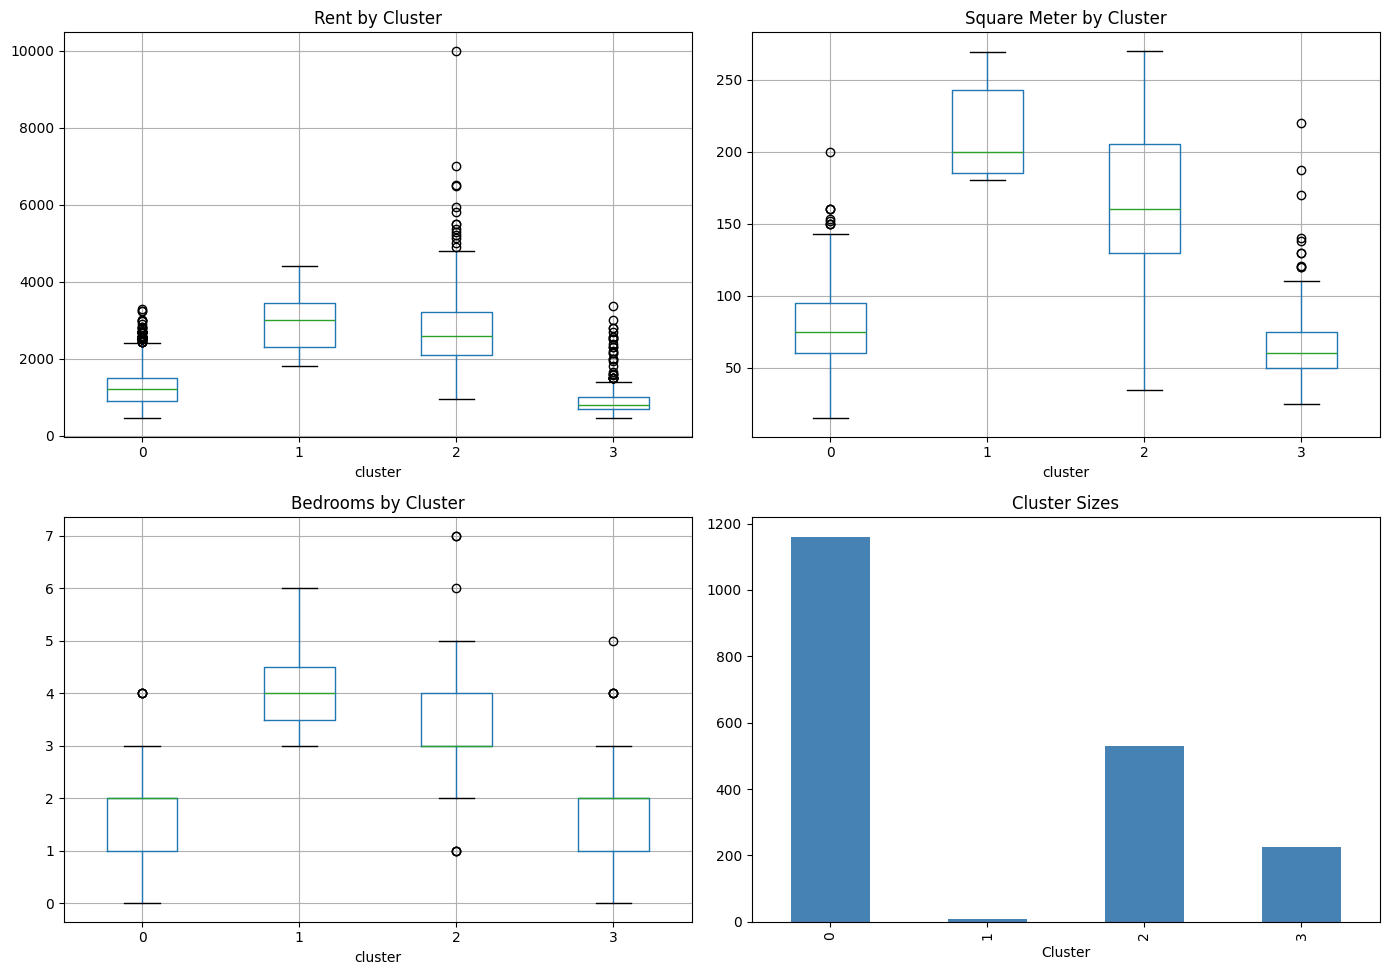

In [39]:
# Radar chart / bar chart comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rent by cluster
df_clean.boxplot(column='rent', by='cluster', ax=axes[0,0])
axes[0,0].set_title('Rent by Cluster')

# Sq.Mt by cluster
df_clean.boxplot(column='square_meters', by='cluster', ax=axes[0,1])
axes[0,1].set_title('Square Meter by Cluster')

# Bedrooms by cluster
df_clean.boxplot(column='bedrooms', by='cluster', ax=axes[1,0])
axes[1,0].set_title('Bedrooms by Cluster')

# Cluster sizes
df_clean['cluster'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Cluster Sizes')
axes[1,1].set_xlabel('Cluster')

plt.suptitle('')
plt.tight_layout()
plt.show()

# To-Do
1. Cluster sizes and give labels
2. Talk to the team and see